In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/instagram.csv')
df.head()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0


### table cols overview
##### **profile pic:** user has profile picture or not
##### **nums/length username:** ratio of number of numerical chars in username to its length
##### **fullname words:** full name in word tokens
##### **nums/length fullname:** ratio of number of numerical characters in full name to its length
##### **name==username:** are username and full name literally the same
##### **description length:** bio length in characters
##### **external URL:** has external URL or not
##### **private:** private or not
##### **#post:** number of posts
##### **followers:** number of followers
##### **follows** number of follows
##### **fake** class (0 genuine, 1 spammer) **(label)**

In [3]:
# informasi dataset
print("Shape:", df.shape)

df.info()
df.describe().T

Shape: (576, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           576 non-null    int64  
 1   nums/length username  576 non-null    float64
 2   fullname words        576 non-null    int64  
 3   nums/length fullname  576 non-null    float64
 4   name==username        576 non-null    int64  
 5   description length    576 non-null    int64  
 6   external URL          576 non-null    int64  
 7   private               576 non-null    int64  
 8   #posts                576 non-null    int64  
 9   #followers            576 non-null    int64  
 10  #follows              576 non-null    int64  
 11  fake                  576 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 54.1 KB


,count,mean,std,min,25%,50%,75%,max
profile pic,576.0,0.701389,0.458047,0.0,0.0,1.0,1.00,1.00
nums/length username,576.0,0.163837,0.214096,0.0,0.0,0.0,0.31,0.92
fullname words,576.0,1.460069,1.052601,0.0,1.0,1.0,2.00,12.00
nums/length fullname,576.0,0.036094,0.125121,0.0,0.0,0.0,0.00,1.00
name==username,576.0,0.034722,0.183234,0.0,0.0,0.0,0.00,1.00
description length,576.0,22.623264,37.702987,0.0,0.0,0.0,34.00,150.00
external URL,576.0,0.116319,0.320886,0.0,0.0,0.0,0.00,1.00
private,576.0,0.381944,0.486285,0.0,0.0,0.0,1.00,1.00
#posts,576.0,107.489583,402.034431,0.0,0.0,9.0,81.50,7389.00
#followers,576.0,85307.236111,910148.457657,0.0,39.0,150.5,716.00,15338538.00


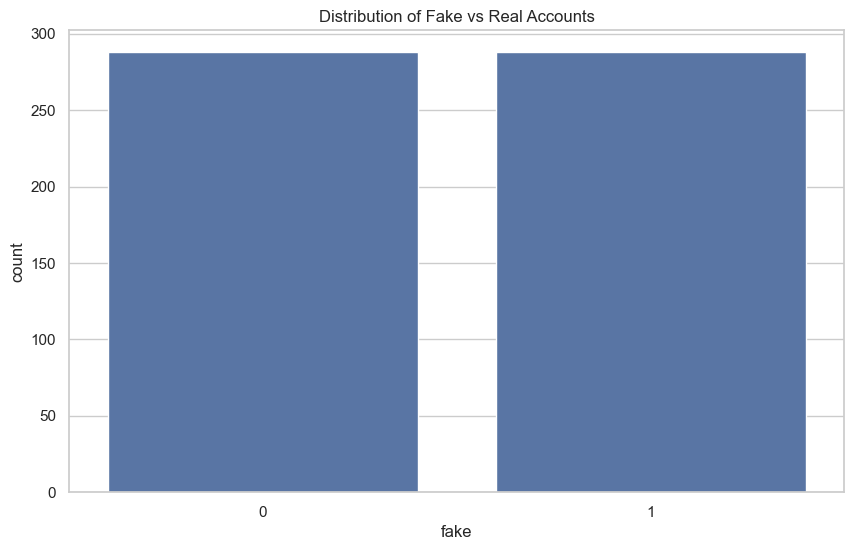

fake
0    288
1    288
Name: count, dtype: int64

In [4]:
# cek inbalanced kolom target
sns.countplot(x='fake', data=df)
plt.title('Distribution of Fake vs Real Accounts')
plt.show()

df['fake'].value_counts(normalize=False)

In [5]:
# unique value tiap kolom
cat_cols = []
num_cols = []

for c in df.columns[:-1]:
    uniq = df[c].nunique()
    if uniq < 10:
        print(f"{c}: \t\t{uniq} unique values")
        cat_cols.append(c)
    else:
        print(f"{c}: \t\tNon Kategorikal")
        num_cols.append(c)

profile pic: 		2 unique values
nums/length username: 		Non Kategorikal
fullname words: 		9 unique values
nums/length fullname: 		Non Kategorikal
name==username: 		2 unique values
description length: 		Non Kategorikal
external URL: 		2 unique values
private: 		2 unique values
#posts: 		Non Kategorikal
#followers: 		Non Kategorikal
#follows: 		Non Kategorikal


In [6]:
# cek unik kolom "fullname words"
print("Unique nums/length username:", df['fullname words'].unique())

Unique nums/length username: [ 0  2  1  4  3  6 12  5 10]


#### `Kolom Kategori`

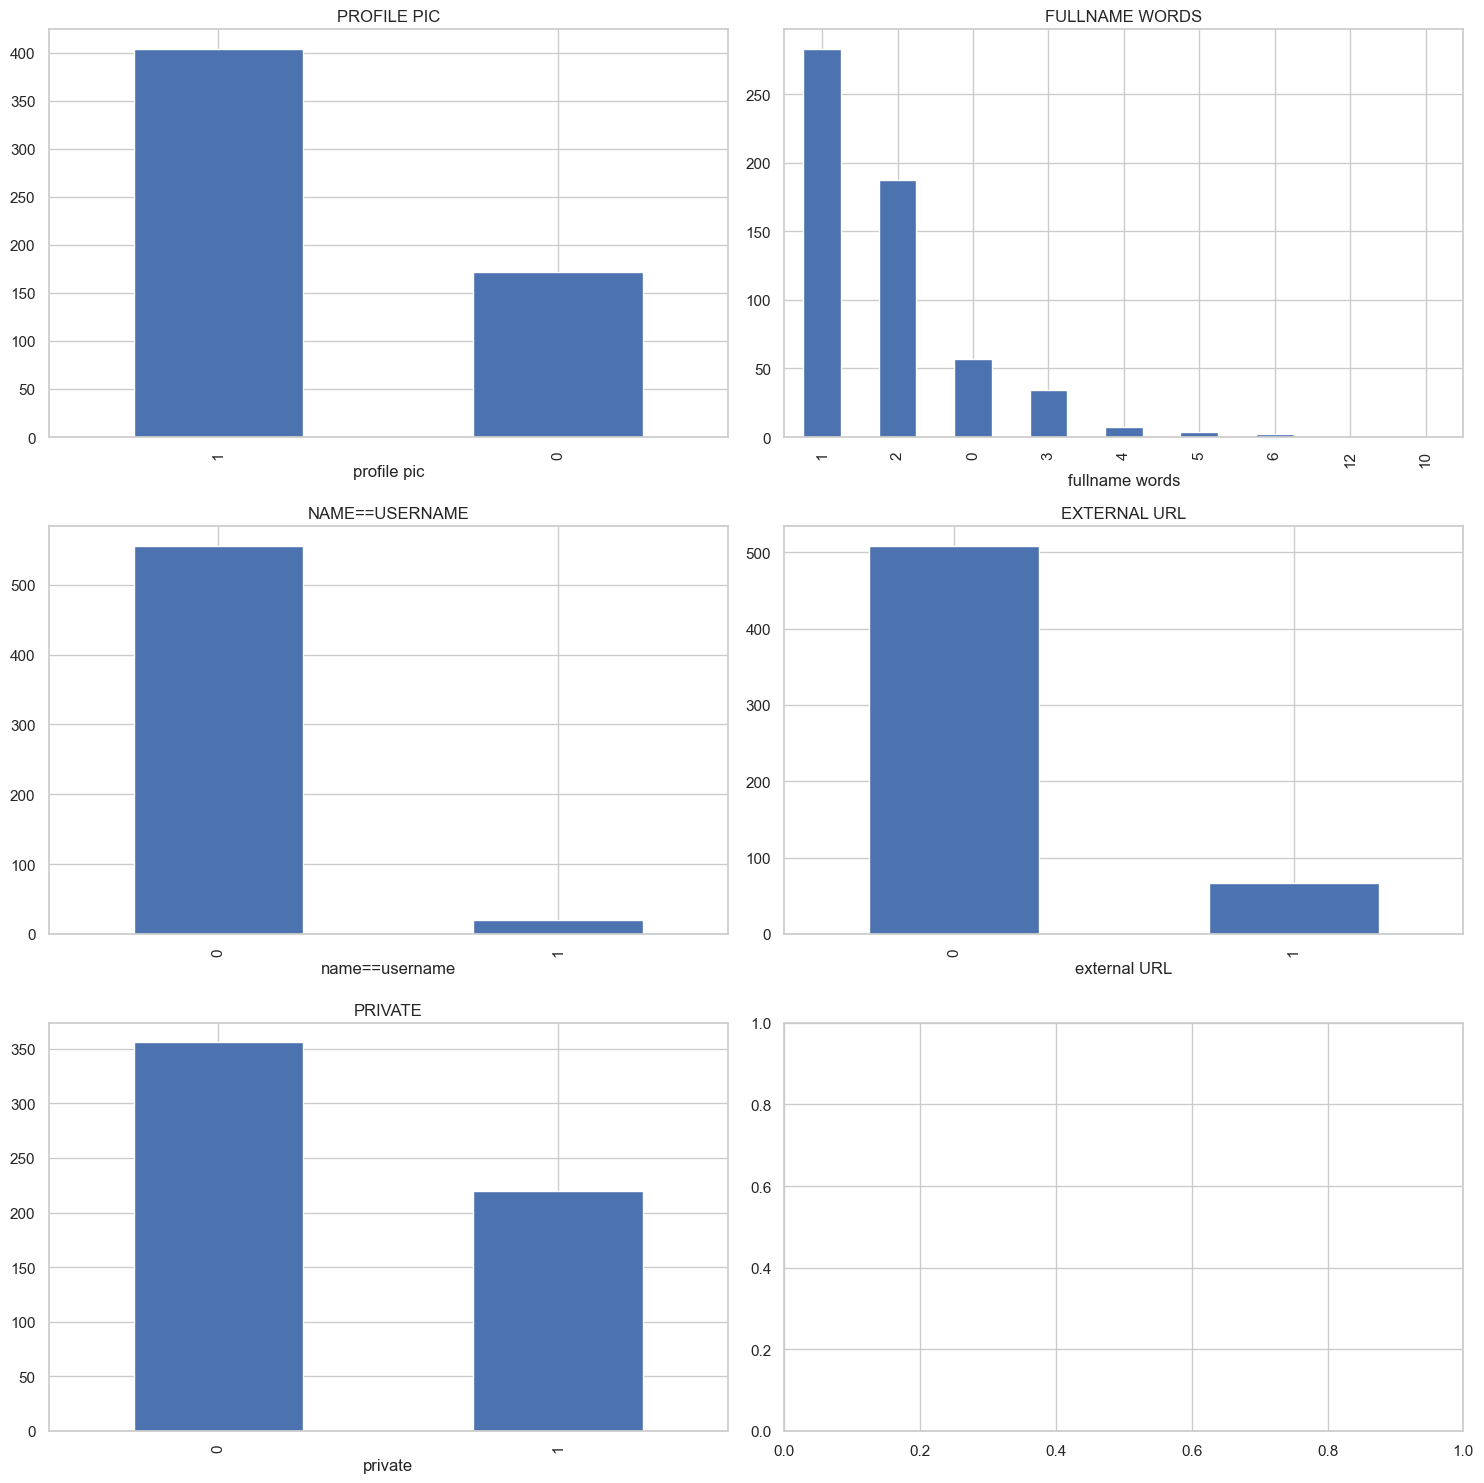

In [7]:
n_cols = 2 
n_rows = (len(cat_cols) + 1) // n_cols 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows)) 
axes = axes.flatten() 

for i, col in enumerate(cat_cols): 
    df[col].value_counts().plot(kind='bar', ax=axes[i]) 
    axes[i].set_title(col.upper()) 
    
plt.tight_layout() 
plt.show()

In [8]:
# drop rows untuk kolom 'fullname words' lebih dari 6. 
print(f'Data yang dihapus: {len(df[df["fullname words"] > 6])} baris' )

df = df[df['fullname words'] <= 6]



Data yang dihapus: 2 baris


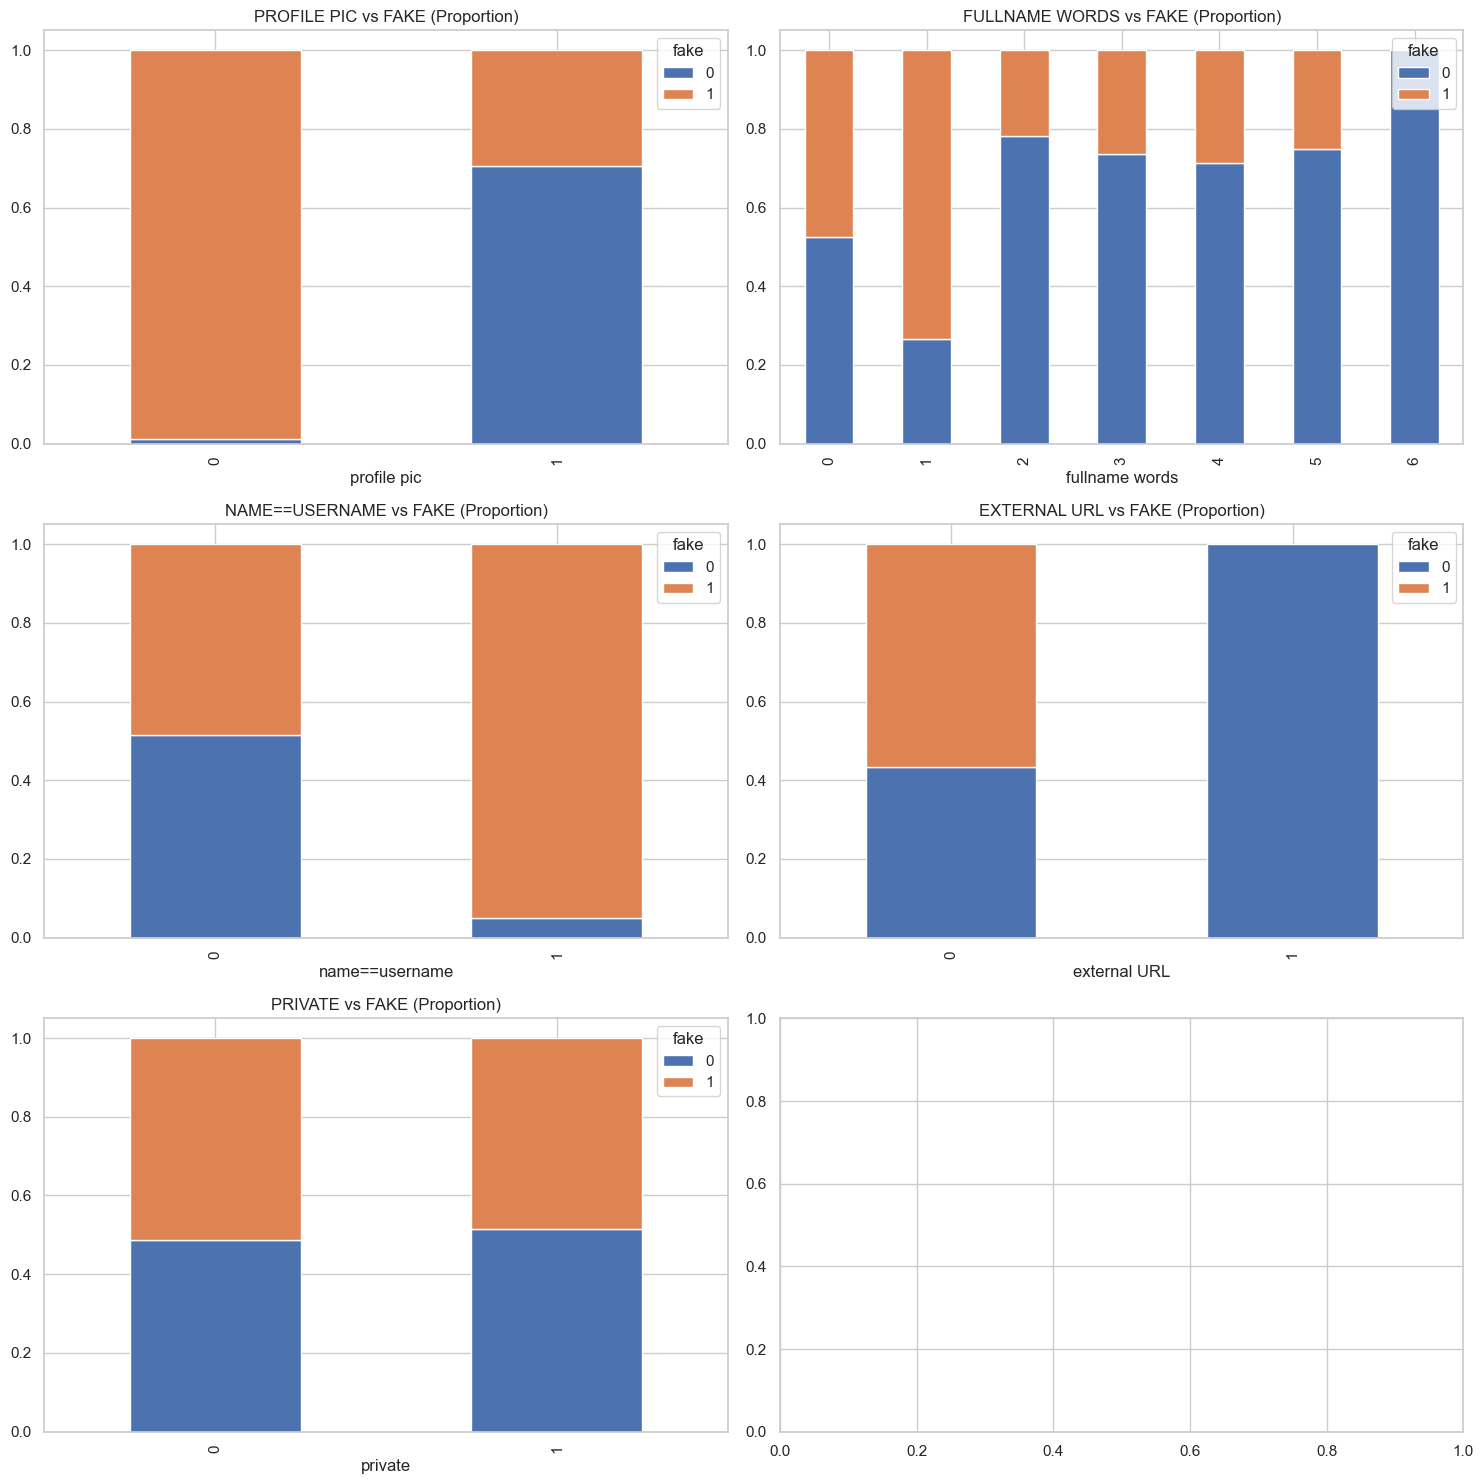

In [9]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows)) 
axes = axes.flatten() 

for i, col in enumerate(cat_cols):
    prop = pd.crosstab(df[col], df['fake'], normalize='index')
    prop.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'{col.upper()} vs FAKE (Proportion)')

plt.tight_layout()
plt.show()

In [10]:
insight1 = f"""
    Didapati insight menarik dari korelasi antara value dari kolom kategorikal dengan kolom target "fake".
    yaitu:
    1). profile pic\t: didapati bahwa value 0 (tidak memiliki profile pic) memiliki proporsi tinggi untuk indikasi akun fake.
    2). fullname words\t: insightless.
    3). name==username\t: cukup tinggi persentase indikasi akun fake dengan kasus nama dan username sama.
    4). external url\t: menurut data, akun yang memiliki external url relatif aman dari indikasi akun fake.
    5). private\t\t: insightless.
"""

print(insight1)


    Didapati insight menarik dari korelasi antara value dari kolom kategorikal dengan kolom target "fake".
    yaitu:
    1). profile pic	: didapati bahwa value 0 (tidak memiliki profile pic) memiliki proporsi tinggi untuk indikasi akun fake.
    2). fullname words	: insightless.
    3). name==username	: cukup tinggi persentase indikasi akun fake dengan kasus nama dan username sama.
    4). external url	: menurut data, akun yang memiliki external url relatif aman dari indikasi akun fake.
    5). private		: insightless.



#### `Kolom Numerik`

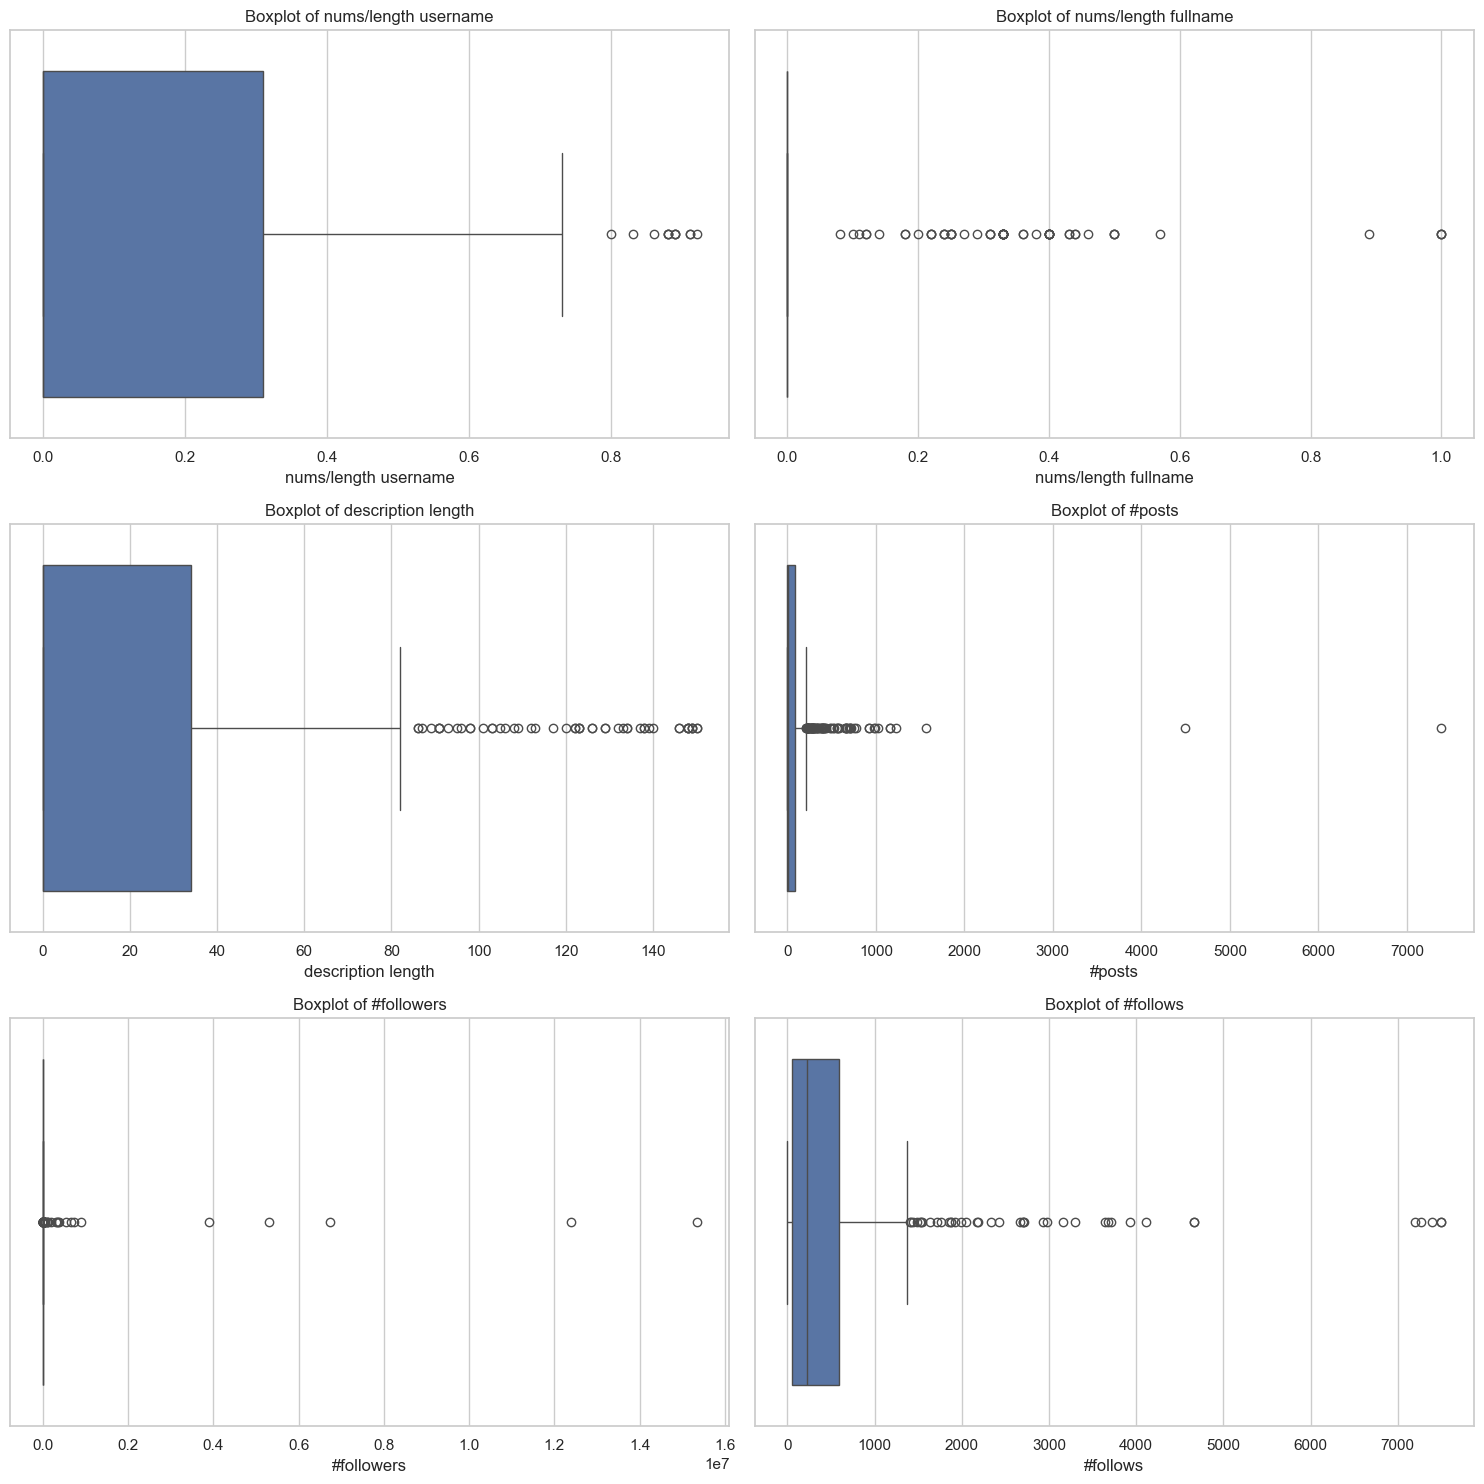

In [11]:
# cek outlier
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    
# hapus subplot kosong (kalau ada)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

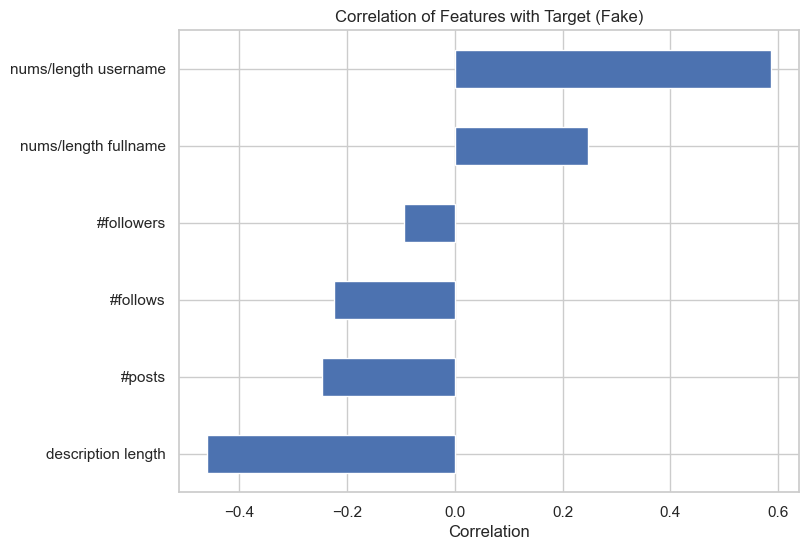

In [12]:
# cek korelasi
corr_target = df[num_cols + ['fake']].corr()['fake'].drop('fake').sort_values()

plt.figure(figsize=(8,6))
corr_target.plot(kind='barh')
plt.title('Correlation of Features with Target (Fake)')
plt.xlabel('Correlation')
plt.show()

### Segmen korelasi (x):
#### |x| > 8, Korelasi Sangat Kuat.
#### |x| > 5, Korelasi Kuat.
#### |x| > 3, Korelasi Sedang.
#### |x| > 1, Korelasi Lemah.
#### |x| > 0, Korelasi Sangat Lemah.


In [13]:
insight2 = f"""
    Korelasi Sangat Kuat: - 
    Korelasi Kuat\t: nums/length username
    Korelasi Sedang\t: description length
    Korelasi Lemah\t: nums/length fullname, #follows, #posts
    Korelasi Sangat Lemah: #followers
"""
print(insight2)


    Korelasi Sangat Kuat: - 
    Korelasi Kuat	: nums/length username
    Korelasi Sedang	: description length
    Korelasi Lemah	: nums/length fullname, #follows, #posts
    Korelasi Sangat Lemah: #followers



#### `Eksplor kolom baru`

In [14]:
# follows/followers ratio
df['follows/followers'] = df['#follows']/(df['#followers']+1) # +1 untuk menghindari pembagian dengan nol
df['follows/followers']

0      0.954046
1      0.194455
2      0.612500
3      1.568675
4      0.828947
         ...   
571    3.568862
572    1.119403
573    3.494845
574    1.258621
575    3.225166
Name: follows/followers, Length: 574, dtype: float64

In [15]:
corr_value = df['follows/followers'].corr(df['fake'])
print(f"Correlation with target: {corr_value:.4f}")

Correlation with target: 0.1203


In [16]:
# follows > followers
df['>follows'] = df['#follows']>df['#followers'] # +1 untuk menghindari pembagian dengan nol
df['>follows']

0      False
1      False
2      False
3       True
4      False
       ...  
571     True
572     True
573     True
574     True
575     True
Name: >follows, Length: 574, dtype: bool

In [17]:
df['>follows'].value_counts()

>follows
True     330
False    244
Name: count, dtype: int64

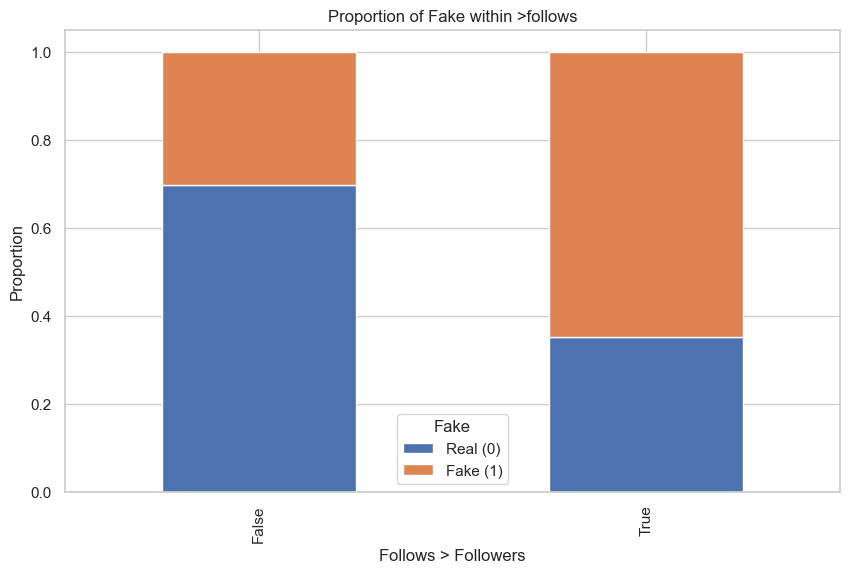

In [18]:
prop = pd.crosstab(df['>follows'], df['fake'], normalize='index')

prop.plot(kind='bar', stacked=True)

plt.title('Proportion of Fake within >follows')
plt.xlabel('Follows > Followers')
plt.ylabel('Proportion')

plt.legend(title='Fake', labels=['Real (0)', 'Fake (1)'])
plt.show()